In [4]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
from matplotlib import pyplot as plt

In [9]:
df=pd.read_csv('shoe_sales.csv')

In [10]:
df.shape

(60, 3)

In [11]:
df.describe

<bound method NDFrame.describe of          date   brand  sold_qty
0    9/1/2023    Nike      24.0
1    9/1/2023  Adidas      14.0
2    9/2/2023    Nike      21.0
3    9/2/2023  Adidas      12.0
4    9/3/2023    Nike      18.0
5    9/3/2023  Adidas      11.0
6    9/4/2023    Nike      22.0
7    9/4/2023  Adidas      13.0
8    9/5/2023    Nike      20.0
9    9/5/2023  Adidas      10.0
10   9/6/2023    Nike      23.0
11   9/6/2023  Adidas      15.0
12   9/7/2023    Nike      19.0
13   9/7/2023  Adidas      16.0
14   9/8/2023    Nike      17.0
15   9/8/2023  Adidas       8.0
16   9/9/2023    Nike      25.0
17   9/9/2023  Adidas      17.0
18  9/10/2023    Nike      14.0
19  9/10/2023  Adidas       7.0
20  9/11/2023    Nike      23.0
21  9/11/2023  Adidas       9.0
22  9/12/2023    Nike      19.0
23  9/12/2023  Adidas     689.0
24  9/13/2023    Nike      16.0
25  9/13/2023  Adidas      11.0
26  9/14/2023    Nike      22.0
27  9/14/2023  Adidas      13.0
28  9/15/2023    Nike      17.0
29  9/

In [12]:
df[df.sold_qty<12].shape

(13, 3)

In [13]:
df_nike=df[df['brand']=='Nike']

In [14]:
df_nike.shape

(30, 3)

In [15]:
df_nike.describe

<bound method NDFrame.describe of          date brand  sold_qty
0    9/1/2023  Nike      24.0
2    9/2/2023  Nike      21.0
4    9/3/2023  Nike      18.0
6    9/4/2023  Nike      22.0
8    9/5/2023  Nike      20.0
10   9/6/2023  Nike      23.0
12   9/7/2023  Nike      19.0
14   9/8/2023  Nike      17.0
16   9/9/2023  Nike      25.0
18  9/10/2023  Nike      14.0
20  9/11/2023  Nike      23.0
22  9/12/2023  Nike      19.0
24  9/13/2023  Nike      16.0
26  9/14/2023  Nike      22.0
28  9/15/2023  Nike      17.0
30  9/16/2023  Nike      21.0
32  9/17/2023  Nike       NaN
34  9/18/2023  Nike      18.0
36  9/19/2023  Nike      15.0
38  9/20/2023  Nike      24.0
40  9/21/2023  Nike      24.0
42  9/22/2023  Nike      16.0
44  9/23/2023  Nike      20.0
46  9/24/2023  Nike      15.0
48  9/25/2023  Nike       NaN
50  9/26/2023  Nike      19.0
52  9/27/2023  Nike      22.0
54  9/28/2023  Nike      21.0
56  9/29/2023  Nike      17.0
58  9/30/2023  Nike      18.0>

In [16]:
val = round(df_nike.sold_qty.median())

In [17]:
df_nike.sold_qty.fillna(val,inplace=True)

C:\Users\bhava\AppData\Local\Temp\ipykernel_7256\496827104.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_nike.sold_qty.fillna(val,inplace=True)


0     24.0
2     21.0
4     18.0
6     22.0
8     20.0
10    23.0
12    19.0
14    17.0
16    25.0
18    14.0
20    23.0
22    19.0
24    16.0
26    22.0
28    17.0
30    21.0
32    20.0
34    18.0
36    15.0
38    24.0
40    24.0
42    16.0
44    20.0
46    15.0
48    20.0
50    19.0
52    22.0
54    21.0
56    17.0
58    18.0
Name: sold_qty, dtype: float64

In [18]:
df_nike.sold_qty.quantile([0.9])

0.9    24.0
Name: sold_qty, dtype: float64

In [20]:
df_adidas=df[df.brand == "Adidas"]
df_adidas.shape


(30, 3)

In [21]:
df_adidas.describe()

,sold_qty
count,30.000000
mean,34.800000
std,123.602366
min,7.000000
25%,10.000000
50%,12.500000
75%,15.000000
max,689.000000


In [23]:
df_adidas.sold_qty.median()

np.float64(12.5)

In [22]:
df_adidas.sold_qty.quantile([0.95])

0.95    18.55
Name: sold_qty, dtype: float64

In [24]:
df_adidas[df_adidas.sold_qty>18.55]

,date,brand,sold_qty
23,9/12/2023,Adidas,689.0
39,9/20/2023,Adidas,19.0


In [26]:
def plot_qty():
    plt.figure(figsize=(15, 6))
    
    dates = df_nike['date']
    
    plt.plot(dates, df_nike['sold_qty'], marker='o', label='Nike', color='blue')
    plt.plot(dates, df_adidas['sold_qty'], marker='o', label='Adidas', color='red')
    
    plt.xlabel('Date')
    plt.ylabel('Total Qty Sold')
    plt.title('Daily Sales Qty for Nike and Adidas in September 2023')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

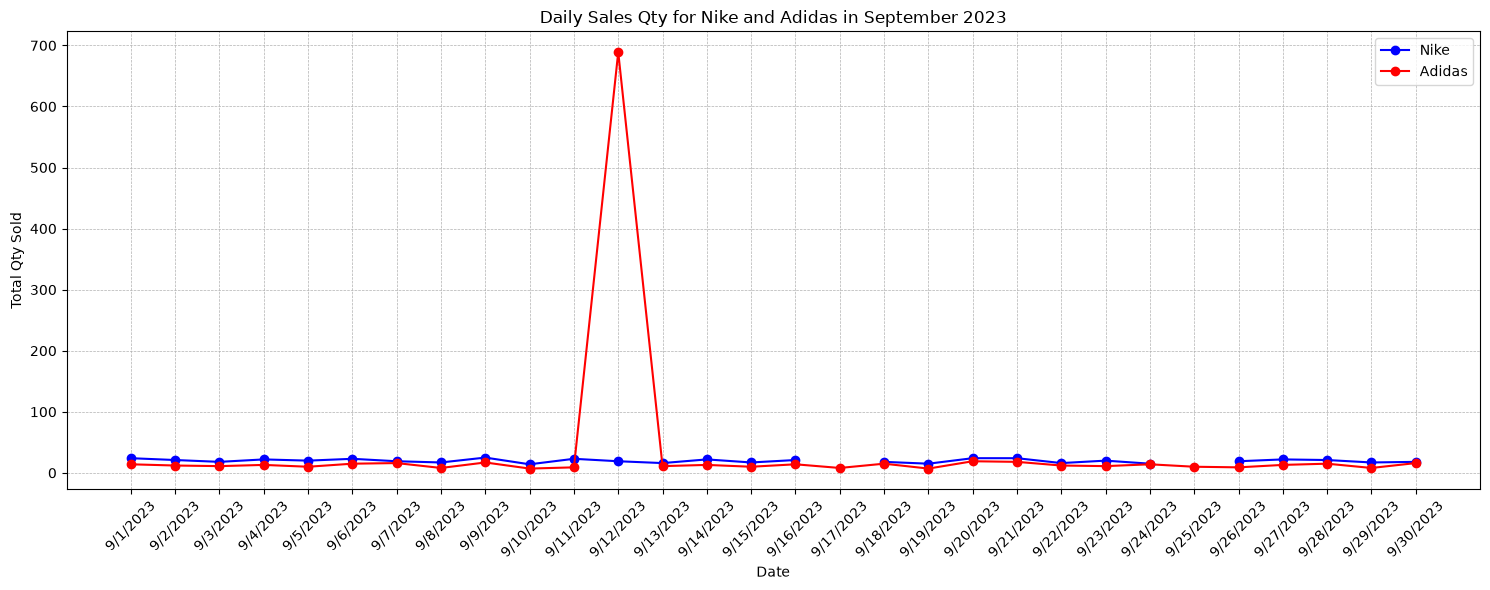

In [27]:
plot_qty()

In [35]:
df_adidas["sold_qty"].describe()

count     30.000000
mean      34.800000
std      123.602366
min        7.000000
25%       10.000000
50%       12.500000
75%       15.000000
max      689.000000
Name: sold_qty, dtype: float64

In [36]:
df_adidas[df.sold_qty>15]

C:\Users\bhava\AppData\Local\Temp\ipykernel_7256\917145973.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_adidas[df.sold_qty>15]


,date,brand,sold_qty
13,9/7/2023,Adidas,16.0
17,9/9/2023,Adidas,17.0
23,9/12/2023,Adidas,689.0
39,9/20/2023,Adidas,19.0
41,9/21/2023,Adidas,18.0
59,9/30/2023,Adidas,16.0


In [37]:
df_adidas["sold_qty"].replace(689, 12, inplace=True)

C:\Users\bhava\AppData\Local\Temp\ipykernel_7256\2013971404.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_adidas["sold_qty"].replace(689, 12, inplace=True)


1     14.0
3     12.0
5     11.0
7     13.0
9     10.0
11    15.0
13    16.0
15     8.0
17    17.0
19     7.0
21     9.0
23    12.0
25    11.0
27    13.0
29    10.0
31    14.0
33     8.0
35    15.0
37     7.0
39    19.0
41    18.0
43    12.0
45    11.0
47    14.0
49    10.0
51     9.0
53    13.0
55    15.0
57     8.0
59    16.0
Name: sold_qty, dtype: float64

In [38]:
df_adidas["sold_qty"].describe()

count     30.000000
mean      34.800000
std      123.602366
min        7.000000
25%       10.000000
50%       12.500000
75%       15.000000
max      689.000000
Name: sold_qty, dtype: float64

In [39]:
df_adidas["sold_qty"].sum()

np.float64(1044.0)